<a href="https://colab.research.google.com/github/BibhusanSilwal/Cricket-Score-Prediction/blob/main/midmatchscoreprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏏 T20 First Innings Score Prediction
This notebook predicts the **final first-innings score** using mid-innings (12 overs) data.

**Important:** Code logic is unchanged; it is only split into cells with explanations.

## 1. Install & Import Dependencies

In [1]:

# pip install datasets scikit-learn xgboost pandas matplotlib seaborn

import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


## 2. Load Dataset from Hugging Face

In [2]:

dataset = load_dataset("Valarmathy/CricketData")
df = dataset['train'].to_pandas()

print(f"Dataset shape: {df.shape}")
print(df.columns.tolist())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/251 [00:00<?, ?B/s]

raw/ball_by_ball_it20.csv:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/425119 [00:00<?, ? examples/s]

Dataset shape: (425119, 35)
['Unnamed: 0', 'Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings', 'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs', 'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket', 'Method', 'Player Out', 'Innings Runs', 'Innings Wickets', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Winner', 'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs', 'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball']


## 3️. Filter First Innings Data

In [3]:

df_first_innings = df[df['Innings'] == 1].copy()


## 4. Feature Engineering: Balls Played

In [4]:

df_first_innings['balls_played'] = df_first_innings['Over'] * 6 + df_first_innings['Ball']


## 5️. Define Mid-Innings Point (12 Overs)

In [5]:

mid_over = 12
mid_balls = mid_over * 6


## 6️. Encode Categorical Variables

In [6]:

venue_le = LabelEncoder()
team_le = LabelEncoder()

df_first_innings['venue_encoded'] = venue_le.fit_transform(df_first_innings['Venue'])
df_first_innings['team_encoded'] = team_le.fit_transform(df_first_innings['Bat First'])


## 7️. Aggregate Mid-Innings Features Per Match

In [7]:

mid_data = []
final_scores = []

for match_id, group in df_first_innings.groupby('Match ID'):
    group = group.sort_values(['Over', 'Ball'])
    mid_group = group[group['balls_played'] <= mid_balls]

    if len(mid_group) > 0:
        runs_so_far = mid_group['Innings Runs'].iloc[-1]
        wickets_so_far = mid_group['Innings Wickets'].iloc[-1]
        balls_so_far = mid_group['balls_played'].iloc[-1]

        venue_code = group['venue_encoded'].iloc[0]
        team_code = group['team_encoded'].iloc[0]

        mid_data.append({
            'match_id': match_id,
            'runs_so_far': runs_so_far,
            'wickets_so_far': wickets_so_far,
            'balls_so_far': balls_so_far,
            'venue_code': venue_code,
            'team_code': team_code
        })

        final_scores.append(group['Innings Runs'].max())


## 8️. Create Final Modeling Dataset

In [8]:

mid_df = pd.DataFrame(mid_data)
mid_df['final_score'] = final_scores

print(mid_df.shape)
mid_df.head()


(1842, 7)


,match_id,runs_so_far,wickets_so_far,balls_so_far,venue_code,team_code,final_score
0,211028,101,3,72,157,22,179
1,211048,94,4,72,37,2,214
2,222678,90,2,72,105,79,133
3,225263,70,4,72,30,22,144
4,225271,95,4,72,157,82,163


## 9️. Train-Test Split

In [9]:

X = mid_df[['runs_so_far', 'wickets_so_far', 'balls_so_far', 'venue_code', 'team_code']]
y = mid_df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 10. Model Training


In [29]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred_lr = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.3f}")

Linear Regression Results
-------------------------
MAE  : 16.92
RMSE : 21.07
R²   : 0.753


In [31]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Results
---------------------
MAE  : 17.75
RMSE : 22.09
R²   : 0.729


In [35]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.3f}")

XGBoost Results
----------------
MAE  : 18.72
RMSE : 23.01
R²   : 0.706


## 11. Model Comparison


In [37]:


comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,16.916693,21.074120,0.753056
1,Random Forest,17.752069,22.092479,0.728614
2,XGBoost,18.722586,23.006478,0.705694


## 12. Evaluation Summary

In [12]:

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,R2
Linear Regression,16.916693,21.074120,0.753056
Random Forest,17.752069,22.092479,0.728614
XGBoost,18.722586,23.006478,0.705694


## 13. Actual vs Predicted Plot


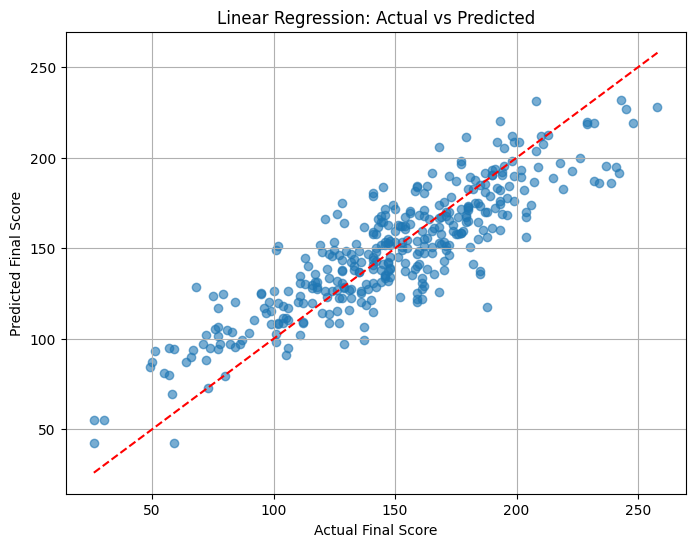

In [17]:
# Linear Regression predictions
lr_model = models['Linear Regression']
y_pred_lr = lr_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


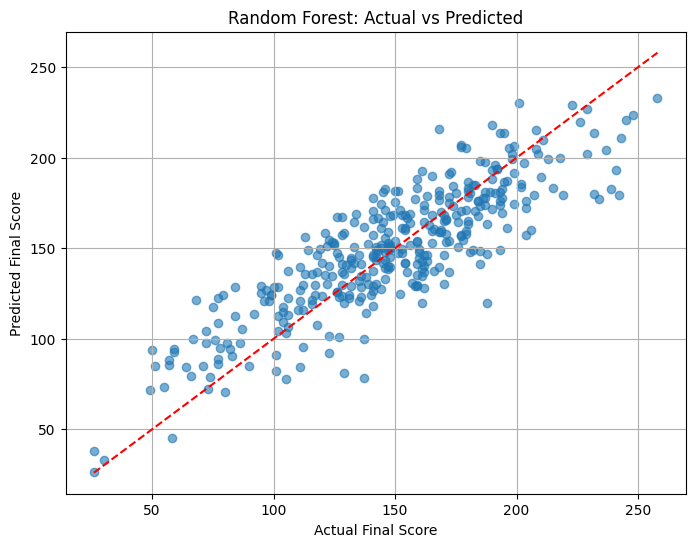

In [18]:
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()


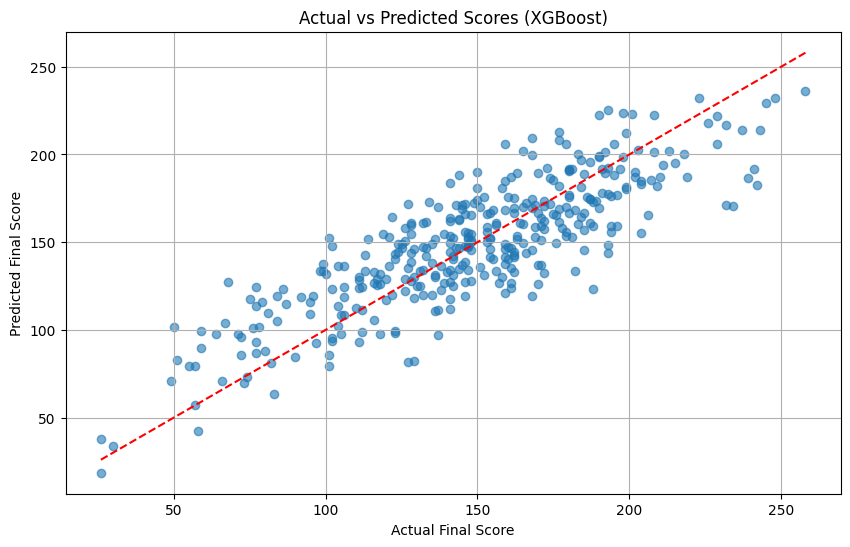

In [13]:

best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Scores (XGBoost)')
plt.grid(True)
plt.show()


## 14. Residual Analysis

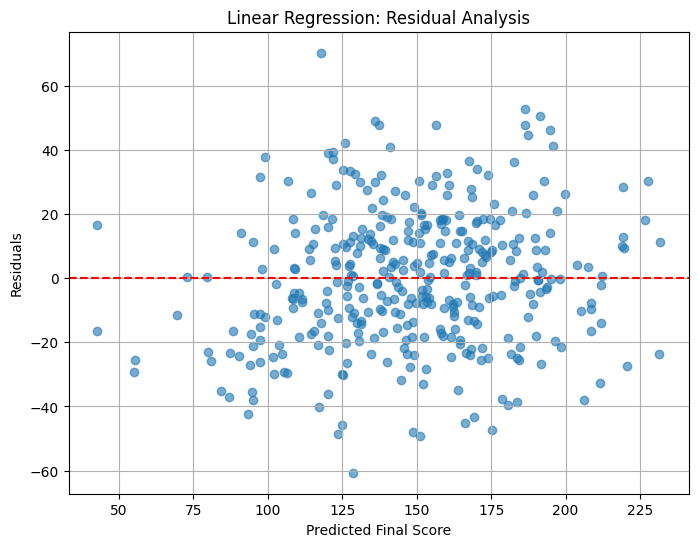

In [19]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Final Score")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Analysis")
plt.grid(True)
plt.show()


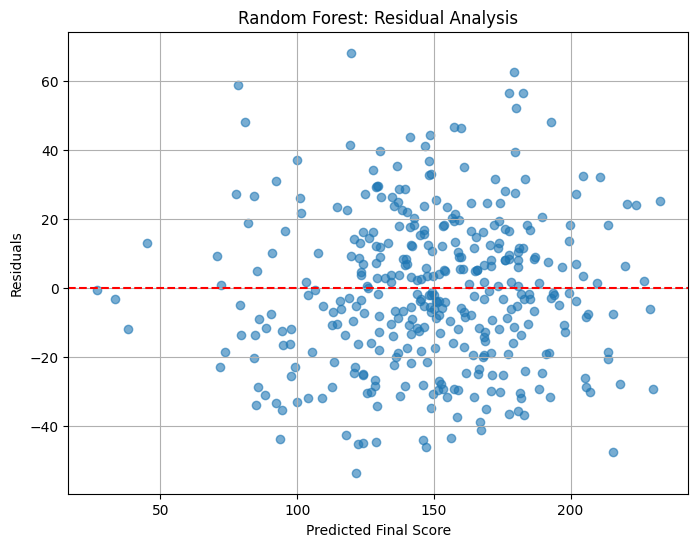

In [20]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Final Score")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Analysis")
plt.grid(True)
plt.show()


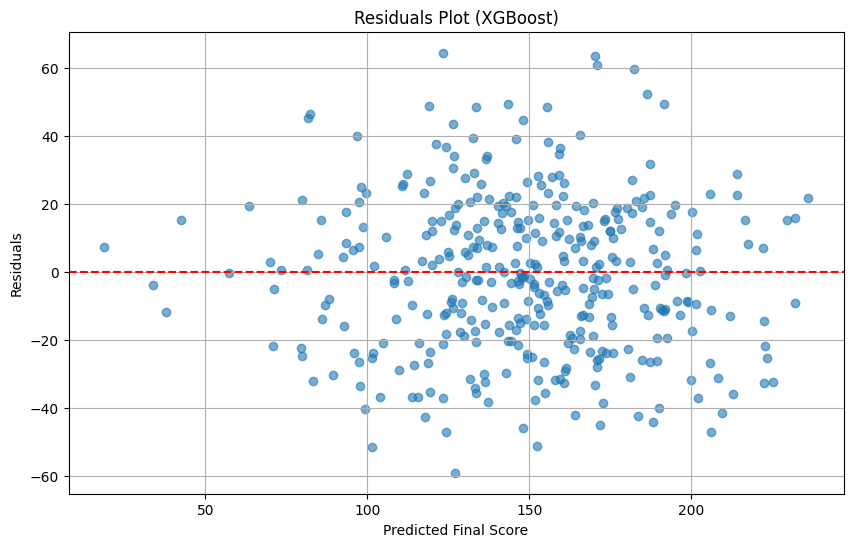

In [14]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Final Score')
plt.ylabel('Residuals')
plt.title('Residuals Plot (XGBoost)')
plt.grid(True)
plt.show()


## 15. Feature Importance

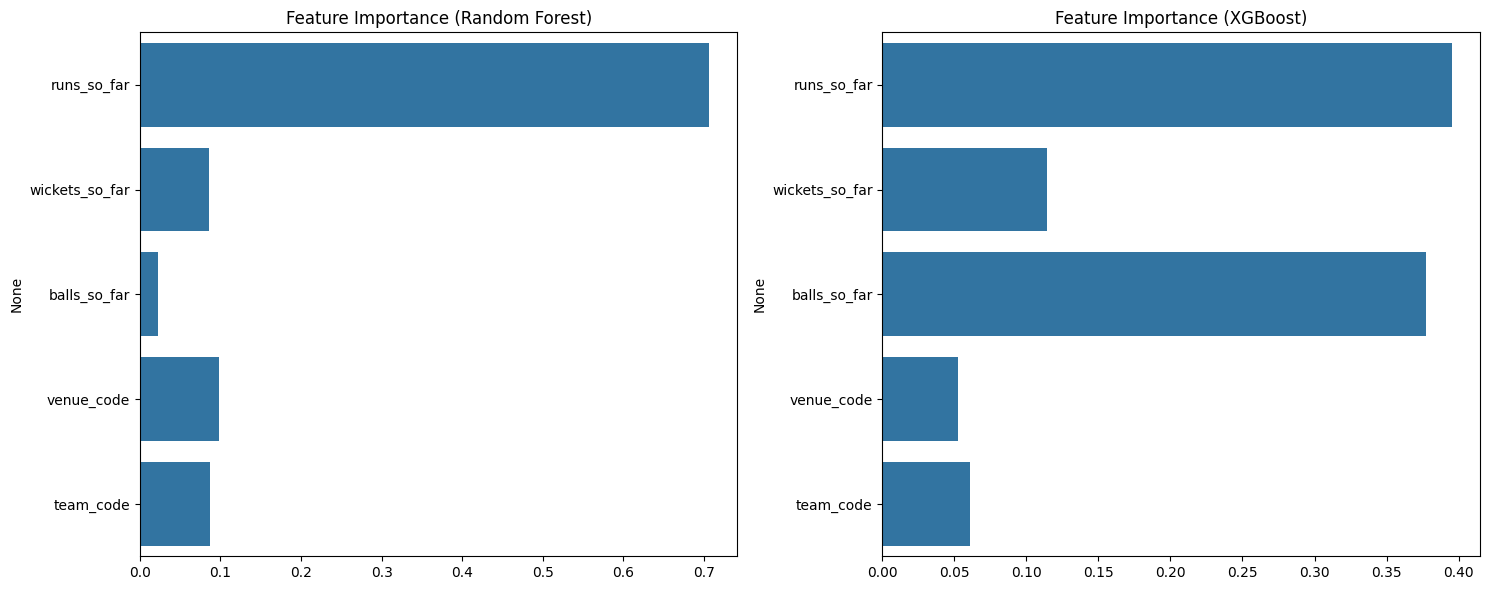

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    x=models['Random Forest'].feature_importances_,
    y=X.columns,
    ax=axes[0]
)
axes[0].set_title('Feature Importance (Random Forest)')

sns.barplot(
    x=best_model.feature_importances_,
    y=X.columns,
    ax=axes[1]
)
axes[1].set_title('Feature Importance (XGBoost)')

plt.tight_layout()
plt.show()


## 16. Model Comparison

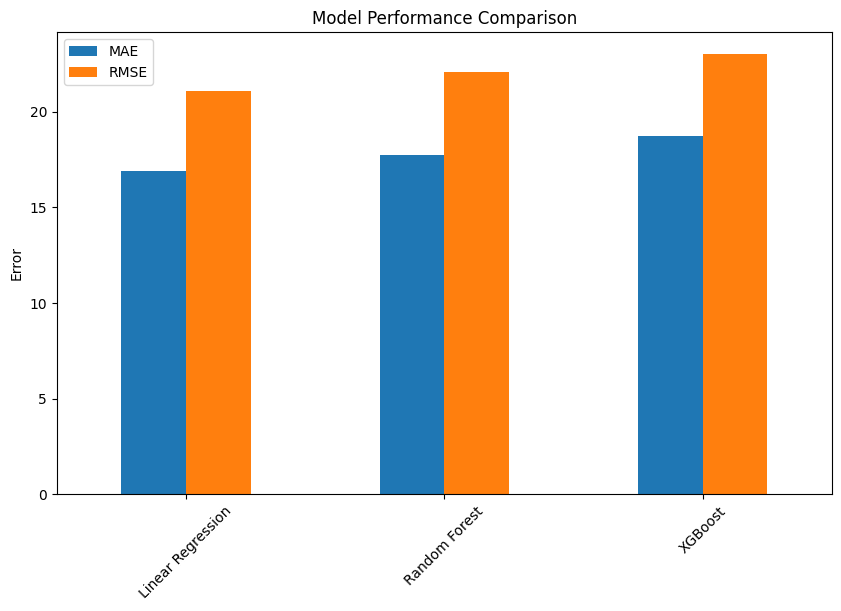

In [16]:

results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.show()
